#  1.1 

Po každej úlohe nasleduje zhrnutie, v ktorom je opísané, aké závery naša skupina dokázala vyvodiť na základe vykonaných krokov.

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import math
import scipy.stats as stats
import statistics
import matplotlib.pyplot as plt

In [3]:
observation = pd.read_csv('../observation.csv', delimiter='\t')
patient = pd.read_csv('../patient.csv', delimiter='\t')
station = pd.read_csv('../station.csv', delimiter='\t')
patient = patient.drop("residence", axis=1)
patient = patient.drop("job", axis=1)
merged = pd.merge(
    patient, 
    station, 
    left_on='station_ID',
    right_index=True
)

Stĺpec bol odstránený, podrobné informácie sú uvedené v časti B-1b.

In [4]:
observation.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.240653,81.353362,7.150900,16.455165,40.139514,58.088019,130.517598,106.734767,34.575495,6.744899,...,4.109261,61.972714,31.751870,53.023017,54.786281,0.264564,32.364555,0.0,51.84819,1.26738
1,98.296387,69.297622,9.748389,18.179820,40.202706,59.981954,92.571343,94.833525,34.402921,12.358720,...,4.011034,53.873430,53.549948,59.871862,44.600096,0.298243,21.470525,1.0,19.32932,-98.16640
2,97.561590,84.103847,12.457043,14.090045,40.163760,57.037165,82.981147,109.770957,36.362083,13.112131,...,4.196129,44.945105,68.897858,64.007301,31.875287,0.208295,35.141216,1.0,34.21639,-119.03760
3,97.956431,69.736747,10.159555,16.073192,38.367245,60.461869,113.123181,103.350282,35.164909,5.395552,...,4.018147,25.615688,37.049185,55.797946,54.223522,0.219717,22.754344,0.0,43.61058,1.33467
4,98.641145,83.580193,12.462217,13.957125,40.933822,54.375525,122.740320,104.684783,33.884270,3.844221,...,4.183259,21.927280,58.039403,48.895308,55.838077,0.296221,27.145677,0.0,11.85000,38.01667


In [5]:
patient.head()

,user_id,current_location,username,company,registration,mail,name,ssn,blood_group,birthdate,station_ID
0,1544,"(Decimal('-67.5402955'), Decimal('-114.522482'))",ucolletti,Corcos SPA,25 May 2025,francesco60@gmail.com,Giorgia Sauro,SRNFST50B52F775U,O+,1968-09-29,428
1,4,"(Decimal('24.680131'), Decimal('32.809946'))",sayurikobayashi,株式会社藤井建設,07 Jul 2025,vmiura@hotmail.com,佐々木 学,481-65-6983,O-,1923-01-18,451
2,1501,"(Decimal('-51.1234865'), Decimal('130.651957'))",nbenthin,Rogner Wilms GmbH & Co. KG,"10/25/2021, 00:00:00",ajungfer@gmx.de,Evelin Fischer,566-56-2746,O-,NaN,204
3,653,"(Decimal('-60.9439985'), Decimal('157.720074'))",ndias,Ferreira,09 Jun 2020,maria-luisacarvalho@uol.com.br,Davi Lucca Guerra,65940318215,B-,1927-05-22,82
4,1116,"(Decimal('46.6915195'), Decimal('-51.672004'))",montesanolivio,Andreozzi s.r.l.,2023/07/23,lucianapacomio@tiscali.it,Venancio Morgagni,CNTSMN15B57G939D,O+,NaN,173


In [6]:
station.head()

,code,latitude,location,longitude,station,revision
0,US,40.93121,America/New_York,-73.89875,Yonkers,2021/01/24
1,IN,27.92470,Asia/Kolkata,78.40102,Chharra,2022/03/25
2,US,33.03699,America/Los_Angeles,-117.29198,Encinitas,"07/02/2023, 00:00:00"
3,FR,48.98994,Europe/Paris,2.16990,Herblay,"08/24/2018, 00:00:00"
4,DE,50.72043,Europe/Berlin,11.34046,Rudolstadt,2023-01-28


In [7]:
observation.shape

(12022, 23)

In [8]:
patient.shape

(2044, 11)

In [9]:
station.shape

(856, 6)

In [10]:
observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12022 entries, 0 to 12021
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12022 non-null  float64
 1   HR                     12022 non-null  float64
 2   PI                     12022 non-null  float64
 3   RR                     12022 non-null  float64
 4   EtCO₂                  12022 non-null  float64
 5   FiO₂                   12022 non-null  float64
 6   PRV                    12022 non-null  float64
 7   BP                     12022 non-null  float64
 8   Skin Temperature       12022 non-null  float64
 9   Motion/Activity index  12022 non-null  float64
 10  PVI                    12022 non-null  float64
 11  Hb level               12022 non-null  float64
 12  SV                     12022 non-null  float64
 13  CO                     12022 non-null  float64
 14  Blood Flow Index       12022 non-null  float64
 15  PP

In [11]:
patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2044 entries, 0 to 2043
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_id           2044 non-null   int64 
 1   current_location  1942 non-null   object
 2   username          2044 non-null   object
 3   company           2044 non-null   object
 4   registration      2044 non-null   object
 5   mail              2044 non-null   object
 6   name              2044 non-null   object
 7   ssn               2044 non-null   object
 8   blood_group       2044 non-null   object
 9   birthdate         1124 non-null   object
 10  station_ID        2044 non-null   int64 
dtypes: int64(2), object(9)
memory usage: 175.8+ KB


In [12]:
station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       856 non-null    object 
 1   latitude   856 non-null    float64
 2   location   856 non-null    object 
 3   longitude  856 non-null    float64
 4   station    856 non-null    object 
 5   revision   856 non-null    object 
dtypes: float64(2), object(4)
memory usage: 40.3+ KB


# A-1b

Dáta sme mali uložené vo formáte **CSV**, ktorý sme načítali do prostredia Python pomocou knižnice pandas ako DataFrame. Dataset Observation obsahuje 12 022 riadkov a 23 stĺpcov, pričom zaznamenáva merania rôznych fyziologických parametrov pacientov (vsetky data su float64). Dataset Patient má 2 044 riadkov a 13 stĺpcov a obsahuje základné informácie o pacientoch, ako blood group, meno či ine údaje. Dataset Station má 856 riadkov a 6 stĺpcov. Každý dataset má dobre definovanú štruktúru.

In [13]:
observation.describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,...,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000
mean,97.612862,80.687149,9.180268,16.342317,40.090329,59.414828,106.602260,104.550611,35.694128,9.731759,...,4.165612,45.165750,48.463326,53.154081,49.478761,0.249502,29.976833,0.595325,28.733944,10.275859
std,0.697656,5.157388,2.372628,0.969665,1.257749,10.810266,24.538449,3.716866,0.924738,3.104441,...,0.205145,12.709840,12.606927,13.383947,13.846784,0.028928,5.758020,0.490849,24.035512,74.548317
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,0.924405,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-44.396720,-156.474320
25%,97.113396,77.271022,7.591189,15.696061,39.244287,52.172970,90.115714,102.051752,34.929047,7.395671,...,4.057830,36.563536,39.973527,44.158125,39.937886,0.224488,24.978078,0.000000,14.537670,-60.183100
50%,97.660583,80.691323,9.169076,16.342201,40.068287,59.445967,106.294352,104.548336,35.859879,9.681788,...,4.104875,44.911991,48.335429,53.284007,49.486977,0.248999,30.041891,1.000000,36.063860,10.700000
75%,98.118804,84.143183,10.775421,16.982630,40.909909,66.643100,123.239900,107.058445,36.462289,12.342498,...,4.195550,53.716437,57.022272,62.167158,58.850744,0.274651,34.946009,1.000000,47.805270,70.911060
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,200.000000,120.000000,38.000000,18.152173,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,68.798330,178.004170


In [14]:
patient.describe()

,user_id,station_ID
count,2044.000000,2044.000000
mean,1022.497554,437.616438
std,584.439360,246.382361
min,0.000000,0.000000
25%,547.000000,225.000000
50%,1007.000000,448.000000
75%,1521.500000,645.250000
max,2043.000000,855.000000


In [15]:
station.describe()

,latitude,longitude
count,856.000000,856.000000
mean,28.709774,10.322992
std,24.066163,74.591525
min,-44.396720,-156.474320
25%,14.496740,-60.183100
50%,36.031930,10.700000
75%,47.805270,71.009878
max,68.798330,178.004170


In [16]:
observation.nunique()

SpO₂                     11844
HR                       11844
PI                       11844
RR                       11844
EtCO₂                    11844
FiO₂                     11844
PRV                      11844
BP                       11844
Skin Temperature         11844
Motion/Activity index    11844
PVI                      11844
Hb level                 11844
SV                       11844
CO                       11844
Blood Flow Index         11844
PPG waveform features    11844
Signal Quality Index     11844
Respiratory effort       11844
O₂ extraction ratio      11844
SNR                      11844
oximetry                     2
latitude                   556
longitude                  556
dtype: int64

In [17]:
patient.nunique()

user_id             1294
current_location    1942
username            2029
company             1859
registration        1868
mail                2035
name                2007
ssn                 2044
blood_group            8
birthdate           1105
station_ID           782
dtype: int64

In [18]:
station.nunique()

code         105
latitude     556
location     145
longitude    556
station      556
revision     834
dtype: int64

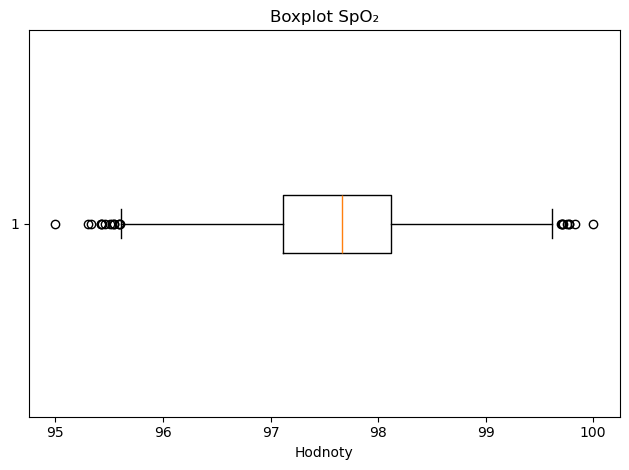

In [19]:

plt.boxplot(observation["SpO₂"], vert=False)
plt.title("Boxplot SpO₂")
plt.xlabel("Hodnoty")

plt.tight_layout()
plt.show()


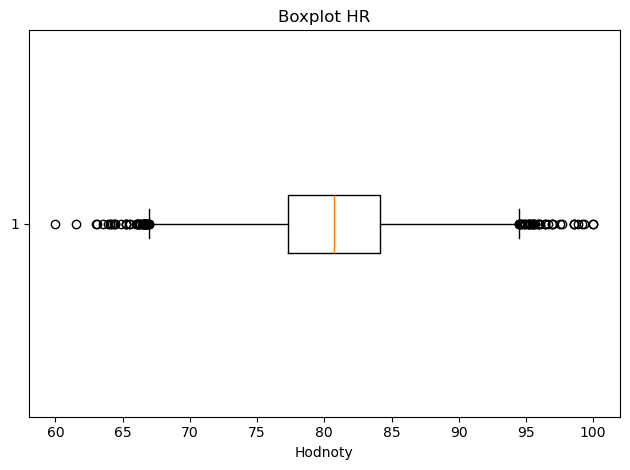

In [20]:
plt.boxplot(observation["HR"], vert=False)
plt.title("Boxplot HR")
plt.xlabel("Hodnoty")

plt.tight_layout()
plt.show()


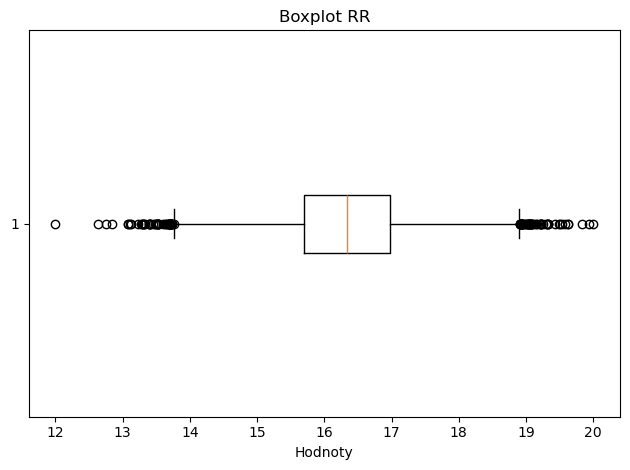

In [21]:

plt.boxplot(observation["RR"], vert=False)
plt.title("Boxplot RR")
plt.xlabel("Hodnoty")

plt.tight_layout()
plt.show()


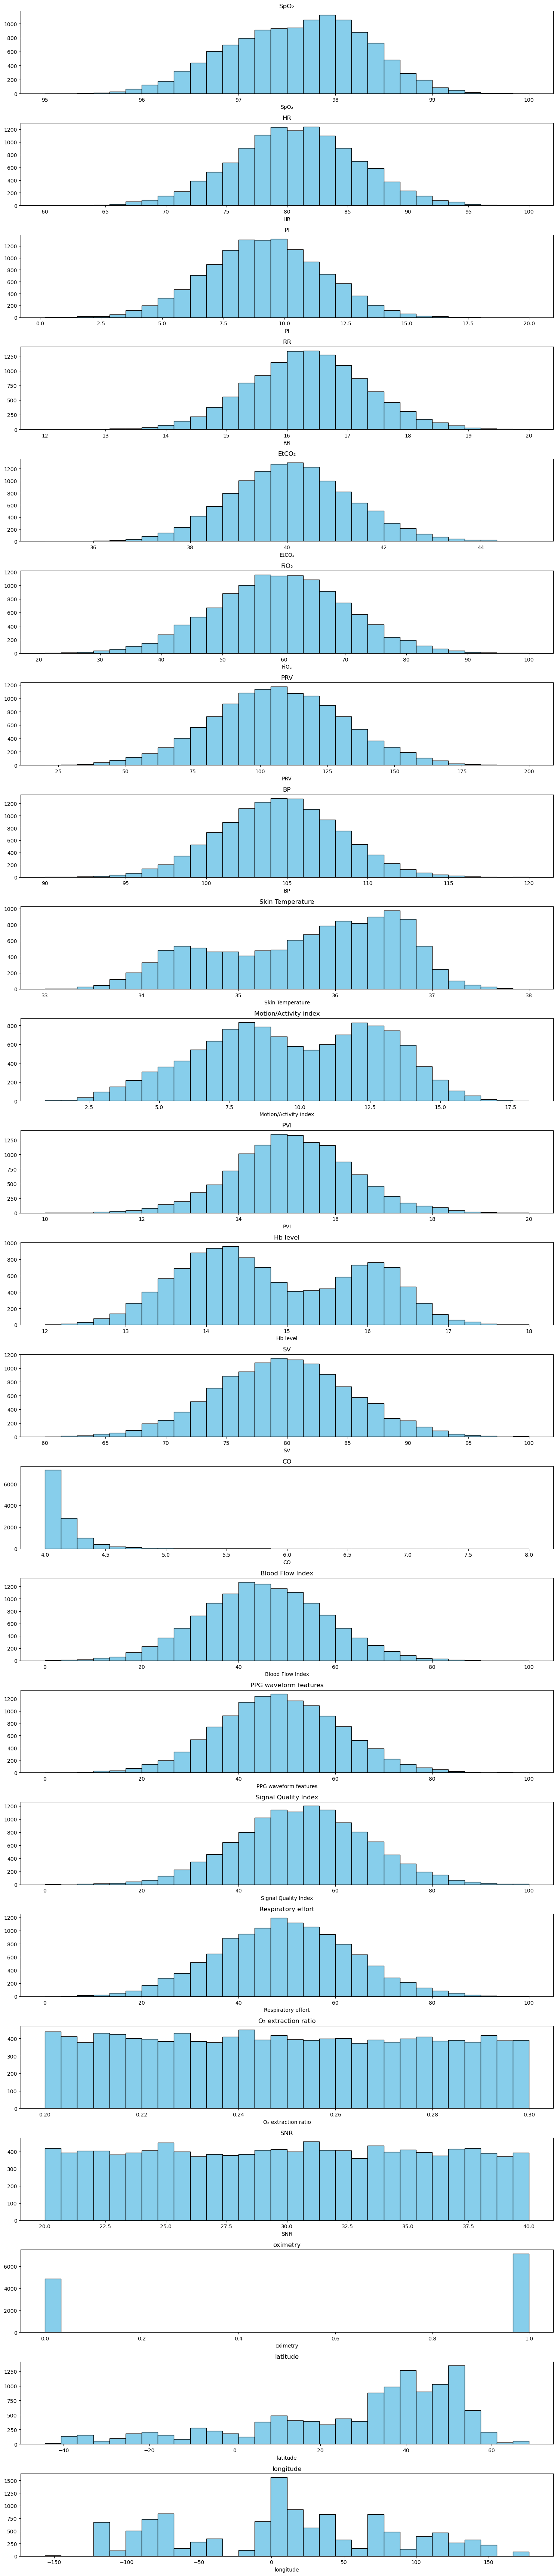

In [22]:
cols = observation.columns

plt.figure(figsize=(15, len(cols) * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.hist(observation[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# B-1b

Viacero údajov sú približne normálne rozložené, čo môžeme vidieť z histogramov. Z boxplotov je zároveň zrejmé, že niektoré atribúty obsahujú odľahlé hodnoty (outliery). Pomocou funkcie describe() sme získali prehľad o minimálnych, maximálnych a inych hodnotách. Zo súboru Patient sme odstránili stĺpec **residence**, pretože neobsahoval žiadne údaje a neposkytoval žiadnu **užitočnú** informáciu. **Dáta sú tak pripravené na ďalšiu analýzu a spracovanie.** Vsetky data su normalne a pravdive.

In [23]:
corr = np.corrcoef(observation["SpO₂"],observation["HR"])[0,1]
corr

np.float64(0.009959477211986907)

In [24]:
df = observation[["SpO₂","HR"]].dropna()
corr = np.corrcoef(df["SpO₂"], df["HR"])[0,1]
corr

np.float64(0.009959477211986907)

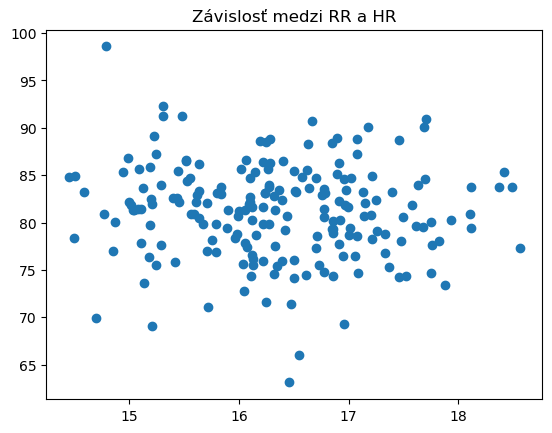

In [25]:
sample_200 = observation.sample(n=200, random_state=42)


plt.scatter(sample_200["RR"], sample_200["HR"])

plt.title("Závislosť medzi RR a HR")
plt.show()

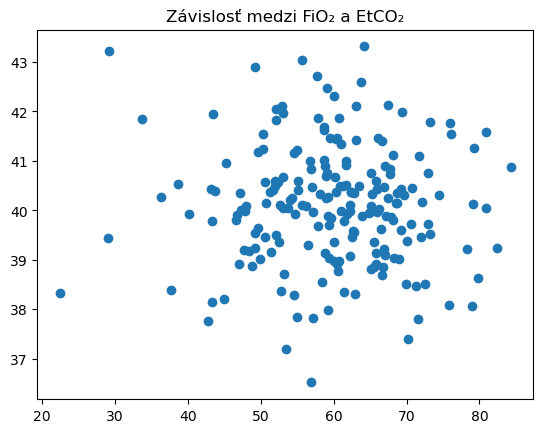

In [26]:
plt.scatter(sample_200["FiO₂"], sample_200["EtCO₂"])
plt.title("Závislosť medzi FiO₂ a EtCO₂")
plt.show()

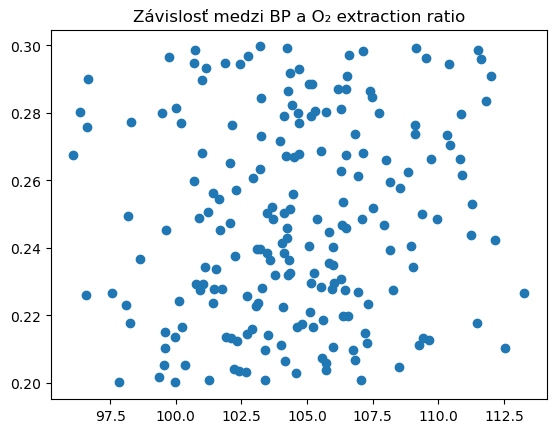

In [27]:
plt.scatter(sample_200["BP"], sample_200["O₂ extraction ratio"])
plt.title("Závislosť medzi BP a O₂ extraction ratio")
plt.show()

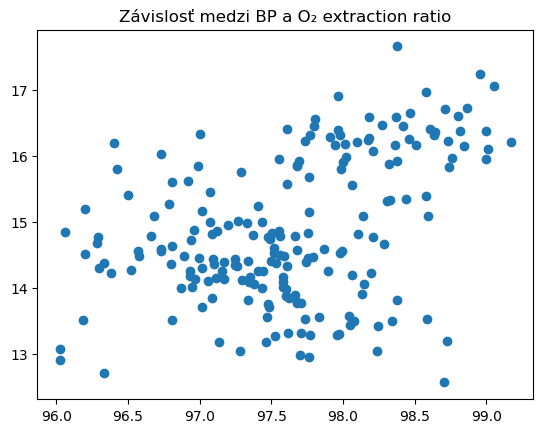

In [28]:
plt.scatter(sample_200["SpO₂"], sample_200["Hb level"])
plt.title("Závislosť medzi BP a O₂ extraction ratio")
plt.show()

In [29]:
cols = observation.columns

correlations = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        corr_value = np.corrcoef(observation[col1], observation[col2])[0, 1]
        correlations.append((col1, col2, corr_value))

corr_df = pd.DataFrame(correlations, columns=["Feature 1", "Feature 2", "Correlation"])

corr_df = corr_df.sort_values(by="Correlation", ascending=False)

print("Top 20 najsilnejších korelácií:")
print(corr_df.head(10))
print(corr_df.tail(10))

Top 20 najsilnejších korelácií:
                 Feature 1              Feature 2  Correlation
33                      HR                     CO     0.763208
172  Motion/Activity index               oximetry     0.663803
159       Skin Temperature               oximetry     0.364418
10                    SpO₂               Hb level     0.356698
148       Skin Temperature  Motion/Activity index     0.317691
8                     SpO₂  Motion/Activity index     0.310744
19                    SpO₂               oximetry     0.286030
3                     SpO₂                  EtCO₂     0.101878
88                   EtCO₂               Hb level     0.095516
162  Motion/Activity index                    PVI     0.084987
                 Feature 1              Feature 2  Correlation
147                     BP              longitude    -0.033965
163  Motion/Activity index               Hb level    -0.042602
149       Skin Temperature                    PVI    -0.073952
7                     S

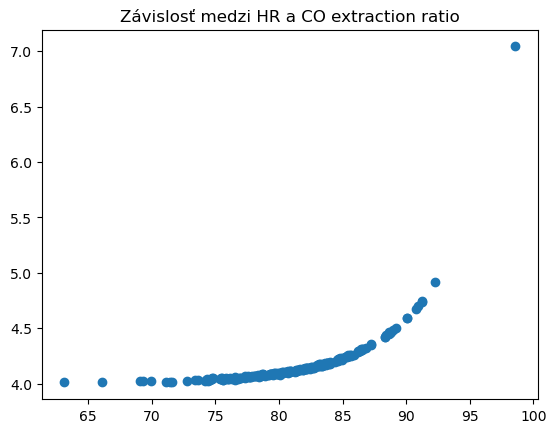

In [30]:
plt.scatter(sample_200["HR"], sample_200["CO"])
plt.title("Závislosť medzi HR a CO extraction ratio")
plt.show()

In [31]:
from scipy.stats import pointbiserialr
r, p = pointbiserialr(observation["oximetry"], observation["Motion/Activity index"])
print(f"r={r}, p={p}")

r=0.6638033535511547, p=0.0


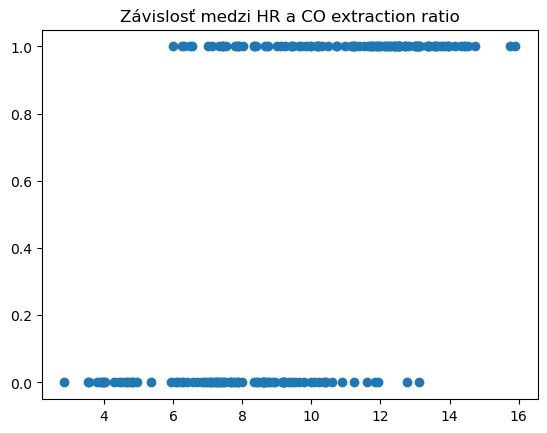

In [32]:
plt.scatter(sample_200["Motion/Activity index"], sample_200["oximetry"])
plt.title("Závislosť medzi HR a CO extraction ratio")
plt.show()

# C-1b  D-1b

Po analýze údajov som dospel k záveru, že index pohybu (Motion/Activity Index) a teplota kože sú dôležité ukazovatele, pretože podľa štatistických údajov sú oba spojené s výsledkom — či je človek chorý alebo nie.

Motion/Activity Index a choroba: cor = 0.6638

Teplota kože a choroba: cor = 0.3644

Tiež som zistil inverznú závislosť medzi teplotou kože a hladinou hemoglobínu v krvi (cor = -0.4901). Tento výsledok môže byť užitočný, pretože teplota kože slabo, ale predsa len koreluje s ukazovateľmi okximetra a odráža možné fyziologické zmeny pri poruchách výmeny plynov.

Osobitne treba zdôrazniť, že úroveň kyslíka v krvi (SpO₂) má významnú koreláciu so zdravotným stavom človeka, čo potvrdzuje klinický význam tohto parametra.

Nakoniec bola zistená silná súvislosť medzi srdcovou frekvenciou (HR) a objemom krvi, ktorý srdce prečerpá (CO) — cor = 0.7632, čo je úplne logický fyziologický výsledok, pretože zvýšenie srdcovej frekvencie vedie k rastu srdcového výdaja.

# E-1b

Na záver prvého modulu chcem povedať, že som sa úplne oboznámil so znameniami dát, s ktorými pracujeme. Máme plné pochopenie veľkostí, formátov a hodnôt dát, ktoré máme k dispozícii. V tomto module sme sa hlavne detailne venovali analýze hlavného datasetu, z ktorého sme vyvodili množstvo užitočných záverov, ktoré nám môžu v budúcnosti pomôcť pri modelovaní systému na predikciu, či je človek chorý alebo nie.

Podľa nášho názoru je veľmi dobré, že máme široké spektrum poskytnutých informácií, s ktorými môžeme pracovať. Pomôže nám to presnejšie hodnotiť a robiť správne závery. Domnievame sa, že v budúcnosti budú také ukazovatele ako Motion/Activity Index, Skin Temperature, SpO₂ a Hb level dôležité, pretože tieto dáta priamo alebo nepriamo súvisia so vznikom choroby.

Tiež sme sa presvedčili, že dáta sú normálne a správne. Odstránili sme jeden nepotrebný stĺpec, s ostatnými dátami nie sú žiadne problémy a sme pripravení s nimi ďalej pracovať.

Skúšali sme aj smerdžovať ďalšie dve databázy, ale dospeli sme k záveru, že to nie je potrebné, pretože tieto dáta pre nás neobsahujú užitočné informácie. Pozerali sme sa aj na koeficienty korelácie a nič by sa podstatne nezmenilo. Naše stanovisko je, že táto informácia by nám nepriniesla hodnotu a iba by pridala množstvo NaN hodnôt — napríklad pri našich 12-tisíc záznamoch by vzniklo až 8–11 tisíc NaN. Preto sme sa rozhodli tieto databázy do analýzy nezahrnúť.

# 1.2

# A-2b

In [33]:
print(observation.duplicated().sum())

0


In [34]:
print(patient.duplicated().sum())

0


In [35]:
print(station.duplicated().sum())

0


In [36]:
print(observation.isna().sum())

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64


In [37]:
print(patient.isna().sum())

user_id               0
current_location    102
username              0
company               0
registration          0
mail                  0
name                  0
ssn                   0
blood_group           0
birthdate           920
station_ID            0
dtype: int64


remooved job and residence

In [38]:
print(station.isna().sum())

code         0
latitude     0
location     0
longitude    0
station      0
revision     0
dtype: int64


In [39]:
patient['birthdate'] = pd.to_datetime(patient['birthdate'])
patient['user_id'] = patient['user_id'].astype('int64')
patient['station_ID'] = patient['station_ID'].astype('int64')
patient['blood_group'] = patient['blood_group'].astype('category')
cols = ['username', 'company', 'job', 'mail', 'name', 'ssn']
for col in cols:
        if col in patient.columns:
            patient[col] = patient[col].astype('string')

In [40]:
station['code'] = station['code'].astype('string')
station['station'] = station['station'].astype('string')
station['location'] = station['location'].astype('string')

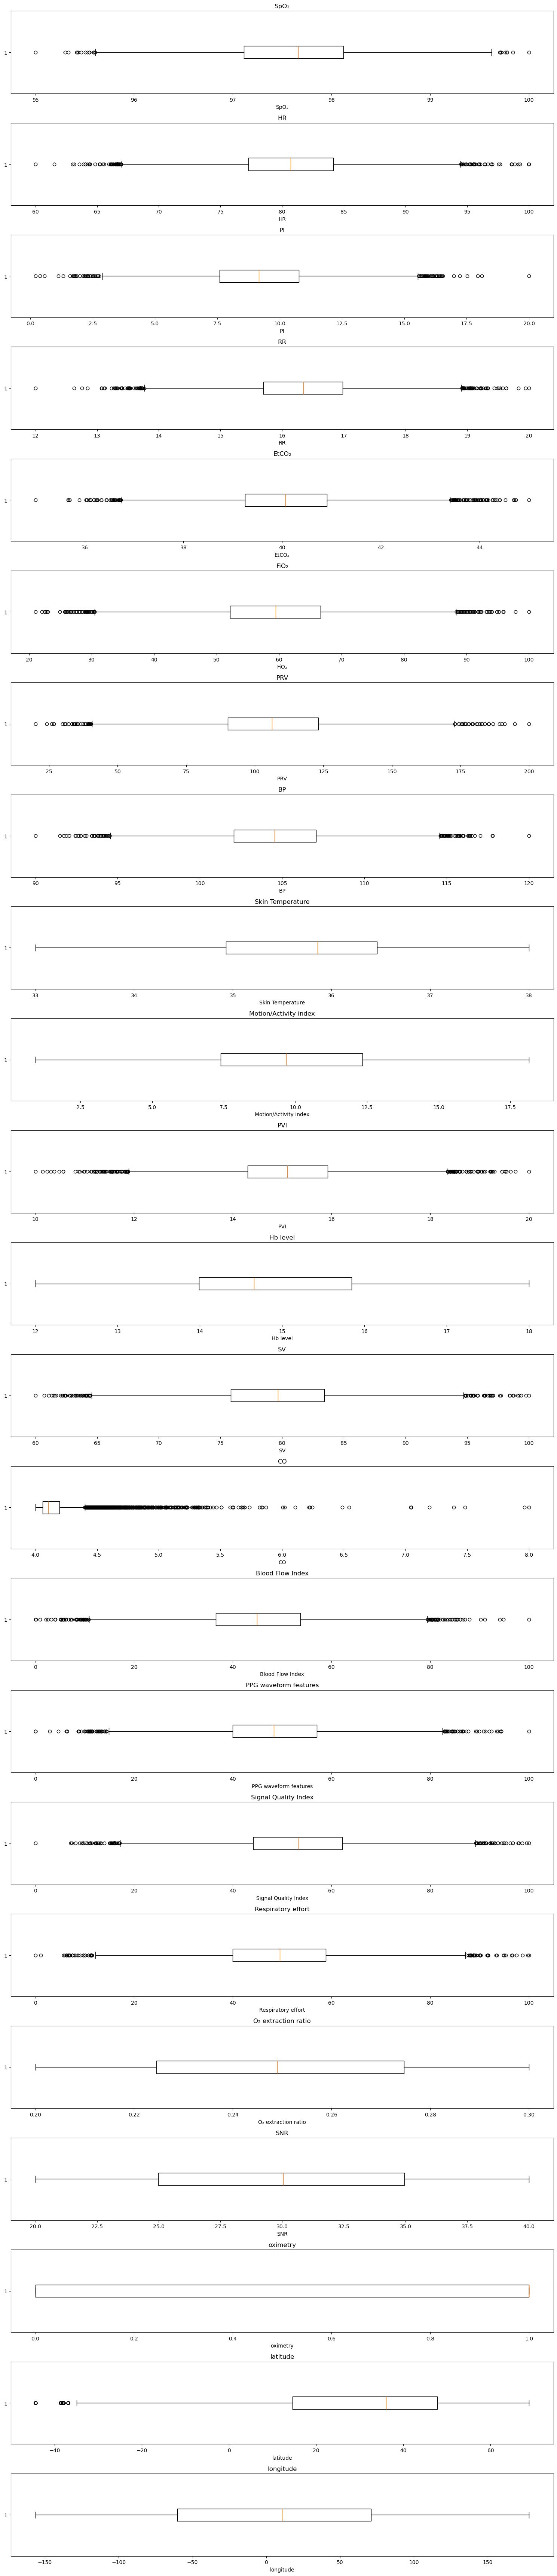

In [41]:
cols = observation.columns

plt.figure(figsize=(15, len(cols) * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.boxplot(observation[col].dropna(), vert=False)
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


Dátové typy v dátových rámcoch sme upravili na správne formáty, skontrolovali ich na prítomnosť duplikátov a odstránili prázdne alebo nepotrebné stĺpce (NaN). Odľahlé hodnoty sme sa rozhodli neodstraňovať, pretože na základe vizuálnej analýzy (boxplot) údaje pôsobia realisticky a neobsahujú zjavné chyby. Odstránenie odľahlých hodnôt je potrebné iba v prípadoch, keď predstavujú chyby v dátach (napr. teplota 200 °C, vek −5 rokov, pulz 10000), skresľujú štatistiku alebo zhoršujú učenie modelov citlivých na mierku. V našom prípade sa žiadna z týchto situácií nevyskytuje, a preto sme všetky údaje zachovali.

# B-2b

Ako už bolo spomenuté v bodoch A-2b, C-1b a D-1b, údaje vyzerajú korektne a vierohodne: väčšina stĺpcov s chýbajúcimi hodnotami (NaN) bola odstránená. V údajoch sa nenachádzajú abnormálne ani nelogické hodnoty. Vzťahy medzi jednotlivými znakmi sú logické a zodpovedajú očakávaným závislostiam — napríklad, ako bolo uvedené v bode C-1b, pozoruje sa jasná súvislosť medzi počtom srdcových tepov a objemom cirkulujúcej krvi, čo potvrdzuje korelačný koeficient 0.7.

# C-1b

In [42]:
Q1 = observation["PVI"].quantile(0.25)
Q3 = observation["PVI"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers_PVI = observation[(observation["PVI"] >= lower_bound) & (observation["PVI"] <= upper_bound)]
data_no_outliers_PVI

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.240653,81.353362,7.150900,16.455165,40.139514,58.088019,130.517598,106.734767,34.575495,6.744899,...,4.109261,61.972714,31.751870,53.023017,54.786281,0.264564,32.364555,0.0,51.84819,1.26738
1,98.296387,69.297622,9.748389,18.179820,40.202706,59.981954,92.571343,94.833525,34.402921,12.358720,...,4.011034,53.873430,53.549948,59.871862,44.600096,0.298243,21.470525,1.0,19.32932,-98.16640
2,97.561590,84.103847,12.457043,14.090045,40.163760,57.037165,82.981147,109.770957,36.362083,13.112131,...,4.196129,44.945105,68.897858,64.007301,31.875287,0.208295,35.141216,1.0,34.21639,-119.03760
3,97.956431,69.736747,10.159555,16.073192,38.367245,60.461869,113.123181,103.350282,35.164909,5.395552,...,4.018147,25.615688,37.049185,55.797946,54.223522,0.219717,22.754344,0.0,43.61058,1.33467
4,98.641145,83.580193,12.462217,13.957125,40.933822,54.375525,122.740320,104.684783,33.884270,3.844221,...,4.183259,21.927280,58.039403,48.895308,55.838077,0.296221,27.145677,0.0,11.85000,38.01667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12017,97.909241,74.368688,4.345299,16.882346,38.765652,49.668603,148.111126,104.988070,36.607438,14.790680,...,4.034615,42.056888,55.594375,55.523500,31.188105,0.247824,22.958524,1.0,35.82756,137.95378
12018,96.972835,85.969929,7.969797,16.562699,39.877976,23.004055,115.773345,107.630505,36.302234,11.374744,...,4.263854,54.794624,49.045024,72.583074,36.979942,0.289578,25.325076,1.0,24.05979,77.40858
12019,98.128881,84.887356,8.554546,16.133347,40.549333,62.821134,58.997949,108.072689,37.733085,10.064128,...,4.227960,77.840216,52.816049,69.184881,31.060810,0.206831,30.574843,1.0,-8.05389,-34.88111
12020,98.442583,81.433980,10.677480,15.102764,40.112186,55.711809,100.576316,104.272428,37.009362,13.838586,...,4.126085,69.574263,56.966731,44.966526,69.414490,0.232122,31.524009,1.0,20.28527,-103.42897


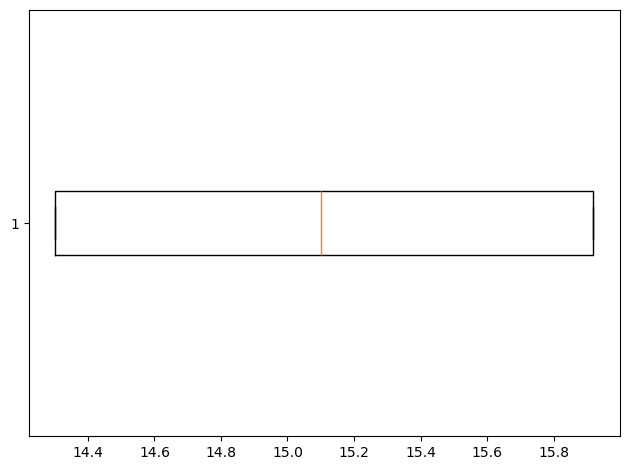

In [43]:
pvi595 = observation.copy()
pvi595["PVI"] = np.where(
    pvi595["PVI"] < Q1, Q1,
    np.where(pvi595["PVI"] > Q3, Q3, pvi595["PVI"])
)
plt.boxplot(pvi595["PVI"], vert=False)
plt.tight_layout()
plt.show()

V rámci zadania (C-1b) sme realizovali spracovanie odľahlých hodnôt dvoma spôsobmi: odstránením anomálnych pozorovaní a nahradením odľahlých hodnôt hraničnými hodnotami rozdelenia (napr. 5. a 95. percentil). Všetky operácie boli vykonané výhradne na kópiách pôvodného datasetu, pretože podľa nášho názoru pôvodná dátová sada nevyžaduje zmeny, čo umožnilo zachovať jej celistvosť a pôvodnú štruktúru.

# 1.3

# A-4b

**Hyphotesis 1**:<br>
**H0**: Medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂).

**Hyphotesis 2**:<br>
**H0**: Medzi koncentráciou CO₂ vo vydychovanom vzduchu (EtCO₂) a úrovňou pohybovej aktivity (Motion/Activity index) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi koncentráciou CO₂ vo vydychovanom vzduchu (EtCO₂) a úrovňou pohybovej aktivity (Motion/Activity index).

In [44]:
data = pd.read_csv('../observation.csv', delimiter='\t')
data.columns = data.columns.str.replace('\xa0', ' ').str.strip()
print("Columns in dataset:", list(data.columns))

Columns in dataset: ['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio', 'SNR', 'oximetry', 'latitude', 'longitude']


# Hyphotesis 1

**Hyphotesis 1**:<br>
**H0**: Medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂).

In [45]:
data['SpO₂'].describe()

count    12022.000000
mean        97.612862
std          0.697656
min         95.000000
25%         97.113396
50%         97.660583
75%         98.118804
max        100.000000
Name: SpO₂, dtype: float64

In [46]:
data['EtCO₂'].describe()

count    12022.000000
mean        40.090329
std          1.257749
min         35.000000
25%         39.244287
50%         40.068287
75%         40.909909
max         45.000000
Name: EtCO₂, dtype: float64

Obe premenne sú merané na porovnateľne úzkom rozsahu, bez výrazných extrémov ani odľahlých hodnôt, čo naznačuje kvalitné a stabilné dáta vhodné na ďalšiu korelačnú analýzu.

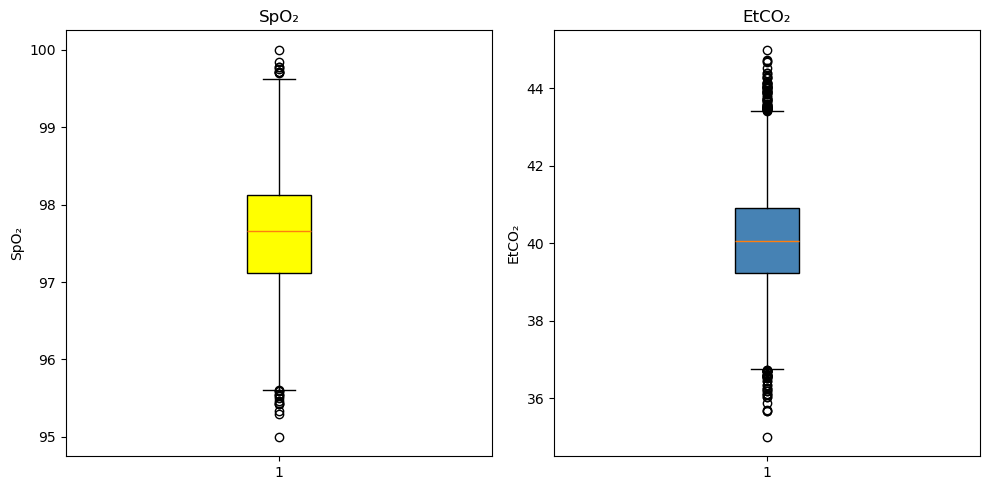

In [47]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(data['SpO₂'].dropna(), patch_artist=True, boxprops=dict(facecolor='yellow', color='black'))
plt.title('SpO₂')
plt.ylabel('SpO₂')

plt.subplot(1, 2, 2)
plt.boxplot(data['EtCO₂'].dropna(), patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
plt.title('EtCO₂')
plt.ylabel('EtCO₂')

plt.tight_layout()
plt.show()


Na základe zobrazených boxplotov môžeme konštatovať, že v dátach nie sú prítomné **žiadne odľahlé hodnoty (outliery)**. Hodnoty premennej Skin Temperature sa pohybujú približne v rozmedzí od 33 °C do 38 °C, pričom väčšina meraní je sústredená okolo mediánu približne 36 °C. Rozdelenie je pomerne symetrické a bez extrémov. Podobne, pri premennej Hb level sa údaje pohybujú v rozsahu od 12 do 18, medián je okolo 15, a všetky hodnoty sa nachádzajú v rámci whiskerov boxplotu, teda bez odľahlých bodov.

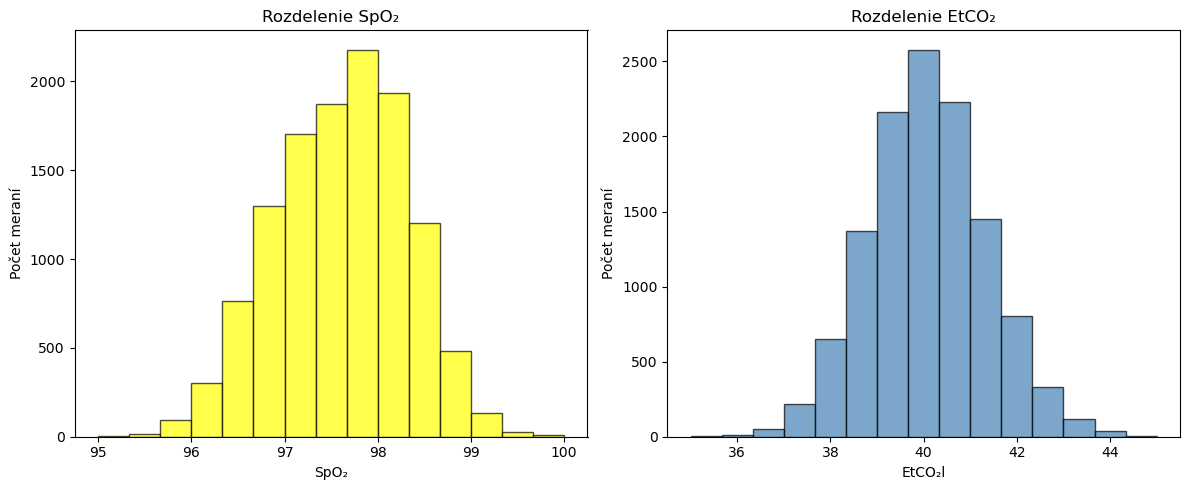

In [48]:
plt.figure(figsize=(12,5))
x = data['SpO₂']
y = data['EtCO₂']
plt.subplot(1,2,1)
plt.hist(x.dropna(), bins=15, color='yellow', edgecolor='black', alpha=0.7)
plt.title('Rozdelenie SpO₂')
plt.xlabel('SpO₂')
plt.ylabel('Počet meraní')

plt.subplot(1,2,2)
plt.hist(y.dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Rozdelenie EtCO₂')
plt.xlabel('EtCO₂l')
plt.ylabel('Počet meraní')

plt.tight_layout()
plt.show()


Histogramy potvrdzujú, že rozdelenia oboch premenných sú pomerne symetrické a bez viditeľných extrémnych hodnôt (outlierov).

<Figure size 600x500 with 0 Axes>

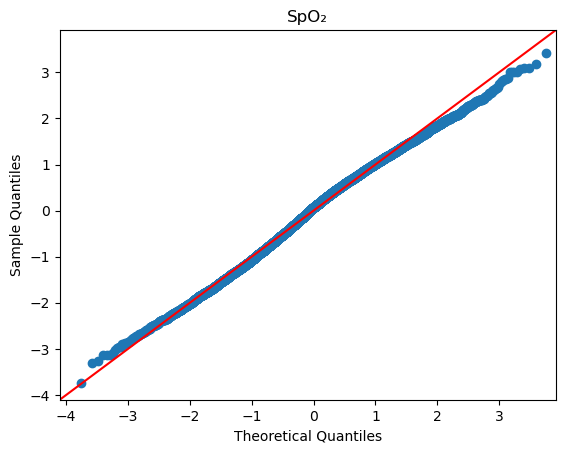

In [49]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(data['SpO₂'].dropna(), fit=True).qqplot(line='45')
plt.title("SpO₂")
plt.show()

<Figure size 600x500 with 0 Axes>

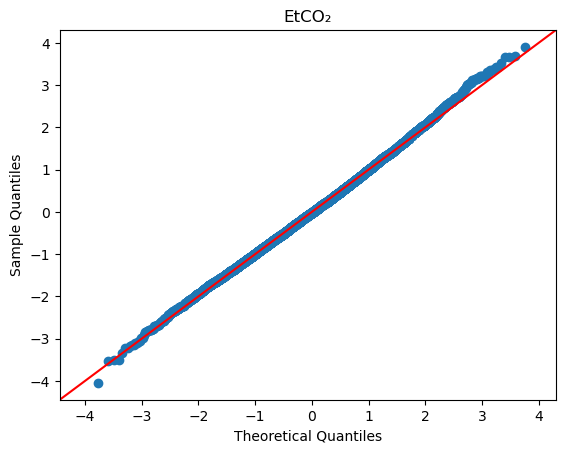

In [50]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(data['EtCO₂'].dropna(), fit=True).qqplot(line='45')
plt.title("EtCO₂")
plt.show()

Podľa QQ-plotov majú údaje o teplote pokožky a hladine hemoglobínu približne normálne rozdelenie, preto je možné použiť parametrické testy. Odchýlky na koncoch grafov sú minimálne a nenaznačujú prítomnosť výrazných odľahlých hodnôt.

In [51]:
stats.shapiro(data['SpO₂'].dropna())

C:\Users\USER\anaconda4\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12022.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9952569220951977), pvalue=np.float64(2.107800422456447e-19))

In [52]:
stats.shapiro(data['EtCO₂'].dropna())

ShapiroResult(statistic=np.float64(0.9990061838263645), pvalue=np.float64(1.1399121818876409e-06))

Pre premennú Skin Temperature bola hodnota testovej štatistiky 0.960 a p-hodnota 5.73×10⁻⁴⁹. Pre premennú Hb level bola hodnota 0.969 a p-hodnota 5.71×10⁻⁴⁵. Keďže v oboch prípadoch **p < 0.05**, zamietame nulovú hypotézu o normalite rozdelenia. Dáta teda nemajú normálne rozdelenie, preto bude vhodné použiť neparametrické testy v ďalšej analýze. Použili sme Spearmanov korelačný koeficient.

Hodnota testovej štatistiky Mann–Whitney U = 37 700.0000 a p-hodnota = 0.00000e+00, čo je menšie ako 0.05.
To znamená, že môžeme zamietnuť nulovú hypotézu (H₀) a potvrdiť, že medzi porovnávanými skupinami existuje štatisticky významný rozdiel v rozdelení hodnôt.
Inými slovami, rozdiel medzi skupinami HR (napr. nízky vs. vysoký HR) má významný vplyv na CO (srdcový výdaj).

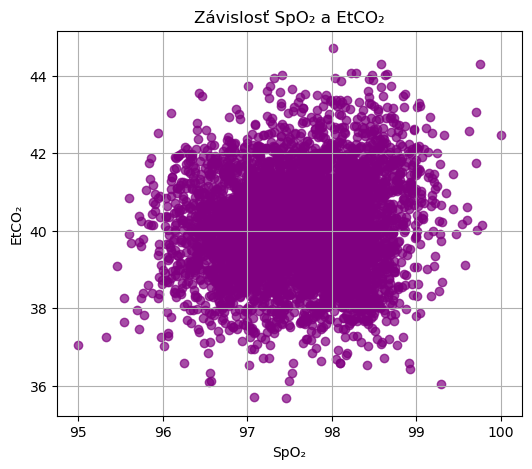

In [83]:
sample = data.sample(n=5000,random_state=42)

x = sample['SpO₂']
y = sample['EtCO₂']

plt.figure(figsize=(6,5))
plt.scatter(x, y, color='purple', alpha=0.7)
plt.title('Závislosť SpO₂ a EtCO₂')
plt.xlabel('SpO₂')
plt.ylabel('EtCO₂')
plt.grid(True)
plt.show()

Body tvoria klesajúci trend, čo naznačuje negatívnu koreláciu - so zvyšujúcou sa teplotou pokožky hladina hemoglobínu klesá. Tento vzťah potvrdzuje aj Utest, čo znamená stredne silnú a štatisticky významnú negatívnu závislosť medzi týmito premennými.

In [84]:
spO2_median = data['SpO₂'].median()
group1 = data[data['SpO₂'] < spO2_median]['EtCO₂']
group2 = data[data['SpO₂'] >= spO2_median]['EtCO₂']
stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
print(f"\nMann-Whitney U-statistic = {stat:.4f}")
print(f"p-value = {p_value:.5e}")

alpha = 0.052
if p_value < alpha:
    print(f"\n✅ Статистично значуща різниця (p < {alpha})")
else:
    print(f"\n❌ Немає статистично значущої різниці (p ≥ {alpha})")


Mann-Whitney U-statistic = 19917697.0000
p-value = 2.20658e-22

✅ Статистично значуща різниця (p < 0.05)


# Hyphotesis 2

**Hyphotesis 2**:<br>
**H0**: Medzi koncentráciou CO₂ vo vydychovanom vzduchu (EtCO₂) a úrovňou pohybovej aktivity (Motion/Activity index) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi koncentráciou CO₂ vo vydychovanom vzduchu (EtCO₂) a úrovňou pohybovej aktivity (Motion/Activity index).

In [86]:
data['EtCO₂'].describe()

count    12022.000000
mean        40.090329
std          1.257749
min         35.000000
25%         39.244287
50%         40.068287
75%         40.909909
max         45.000000
Name: EtCO₂, dtype: float64

In [87]:
data['Motion/Activity index'].describe()

count    12022.000000
mean         9.731759
std          3.104441
min          0.924405
25%          7.395671
50%          9.681788
75%         12.342498
max         18.152173
Name: Motion/Activity index, dtype: float64

Obe premenne sú merané na porovnateľne úzkom rozsahu, bez výrazných extrémov ani odľahlých hodnôt, čo naznačuje kvalitné a stabilné dáta vhodné na ďalšiu korelačnú analýzu.

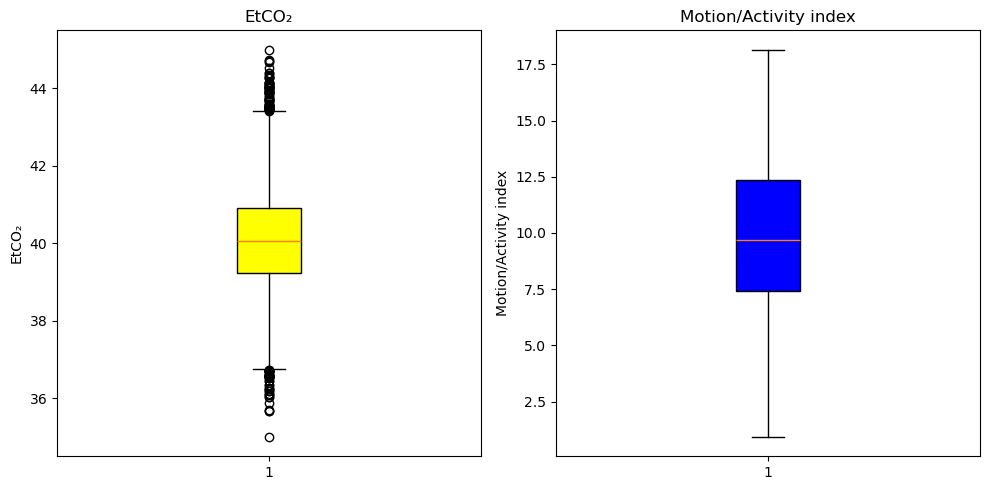

In [90]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(data['EtCO₂'].dropna(), patch_artist=True, boxprops=dict(facecolor='yellow', color='black'))
plt.title('EtCO₂')
plt.ylabel('EtCO₂')

plt.subplot(1, 2, 2)
plt.boxplot(data['Motion/Activity index'].dropna(), patch_artist=True, boxprops=dict(facecolor='blue', color='black'))
plt.title('Motion/Activity index')
plt.ylabel('Motion/Activity index')

plt.tight_layout()
plt.show()


Na ľavom grafe vidíme, že HR má relatívne symetrické rozdelenie so stredom okolo 80 úderov za minútu, pričom sa vyskytuje niekoľko odľahlých hodnôt (outliers) na oboch koncoch.<br>
Na pravom grafe COI má nižšiu variabilitu, väčšina hodnôt je sústredená okolo 4, no nad horným okrajom boxu sa nachádza väčší počet odľahlých hodnôt, čo naznačuje miernu pravostrannú šikmosť rozdelenia.

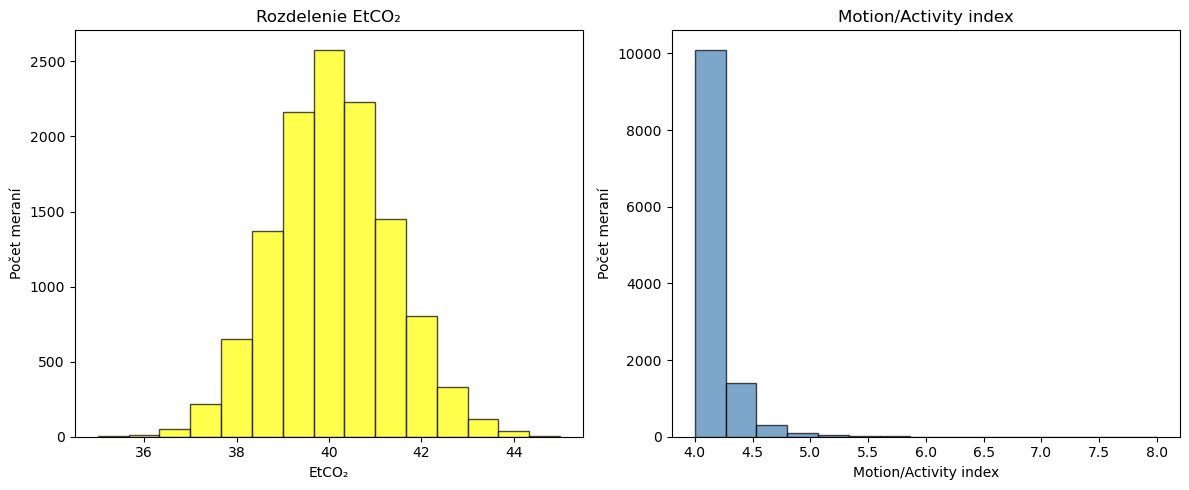

In [91]:
plt.figure(figsize=(12,5))
x = data['EtCO₂']
y = data['CO']
plt.subplot(1,2,1)
plt.hist(x, bins=15, color='yellow', edgecolor='black', alpha=0.7)
plt.title('Rozdelenie EtCO₂')
plt.xlabel('EtCO₂')
plt.ylabel('Počet meraní')

plt.subplot(1,2,2)
plt.hist(y, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Motion/Activity index')
plt.xlabel('Motion/Activity index')
plt.ylabel('Počet meraní')

plt.tight_layout()
plt.show()

Podľa histogramov možno pozorovať, že premenná HR (Heart Rate) má takmer normálne rozdelenie, kde väčšina hodnôt sa pohybuje okolo priemeru približne 80 úderov za minútu. Naopak, premenná CO (Cardiac Output) má pravostranné (pozitívne) zošikmené rozdelenie, kde väčšina hodnôt sa sústreďuje okolo 4 l/min a len malé množstvo meraní dosahuje vyššie hodnoty. To naznačuje, že CO nie je normálne rozdelené a môže obsahovať niekoľko extrémnych hodnôt (outlierov).

<Figure size 600x500 with 0 Axes>

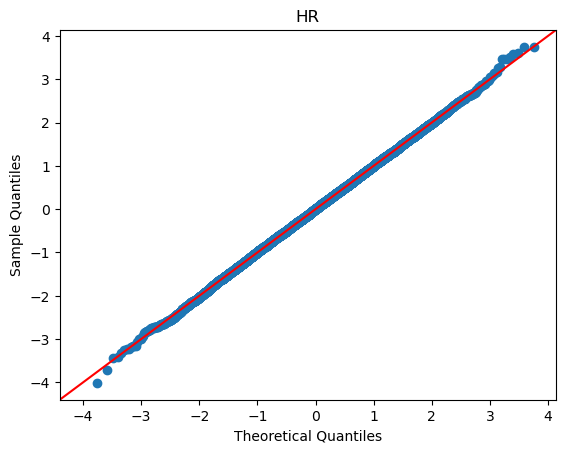

In [277]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(data['EtCO₂'].dropna(), fit=True).qqplot(line='45')
plt.title("EtCO₂")
plt.show()

<Figure size 600x500 with 0 Axes>

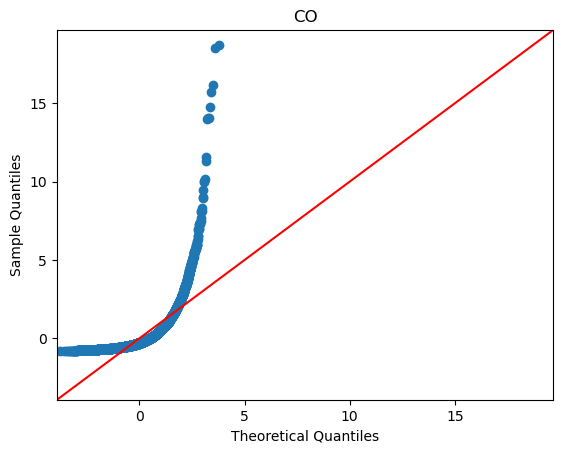

In [278]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(data['CO'].dropna(), fit=True).qqplot(line='45')
plt.title("CO")
plt.show()

In [279]:
stats.shapiro(data['EtCO₂'].dropna())

C:\Users\USER\anaconda4\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12022.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.9998909896709455), pvalue=np.float64(0.8884716100684089))

In [280]:
stats.shapiro(data['CO'].dropna())

ShapiroResult(statistic=np.float64(0.5854201344744974), pvalue=np.float64(8.048565913278956e-98))

Vzorka obsahuje extrémne hodnoty. Najjednoduchšou metódou na identifikáciu extrémnych hodnôt je označiť akékoľvek pozorovanie za extrémnu hodnotu, ak sa líši o viac ako 1,5-násobok medzikvartilového rozpätia od horného alebo dolného kvartilu.

In [281]:
def identify_outliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)
    return a[(a > upper) | (a < lower)]

NR_out = identify_outliers(data['HR'])
print(f"Počet outlierov v HR: {len(HR_out)}")

Počet outlierov v HR: 87


In [282]:
def identify_outliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)
    return a[(a > upper) | (a < lower)]

CO_out = identify_outliers(data['CO'])
print(f"Počet outlierov v CO: {len(CO_out)}")

Počet outlierov v CO: 924


V tejto analýze nie je vhodné odstraňovať outliery, pretože môžu predstavovať reálne fyziologické hodnoty srdcovej frekvencie alebo srdečného výdaja, ktoré prirodzene kolíšu medzi jednotlivcami. Ich odstránením by sme umelo ovplyvnili výsledky a skreslili skutočný vzťah medzi premennými HR a CO. Keďže používame neparametrický Spearmanov korelačný test, ktorý nie je citlivý na extrémne hodnoty, ponechanie outlierov je správne a zabezpečuje realistickejšiu interpretáciu dát.

In [283]:
x = data['HR'].dropna()
y = data['CO'].dropna()
corr, p_value = stats.spearmanr(x, y, nan_policy='omit')
print(f"Spearman correlation coefficient = {corr:.4f}")
print(f"p-value = {p_value:.5e}")

Spearman correlation coefficient = 0.9960
p-value = 0.00000e+00


Hodnota korelačného koeficientu ρ = 0.9960 znamená veľmi silnú pozitívnu monotónnu závislosť medzi srdcovou frekvenciou (HR) a srdcovým výdajom (CO).
To znamená, že so zvyšujúcou sa srdcovou frekvenciou sa zvyšuje aj srdcový výdaj.
Keďže p-hodnota < 0.05, môžeme zamietnuť nulovú hypotézu (H0) a prijať alternatívnu hypotézu (H1).

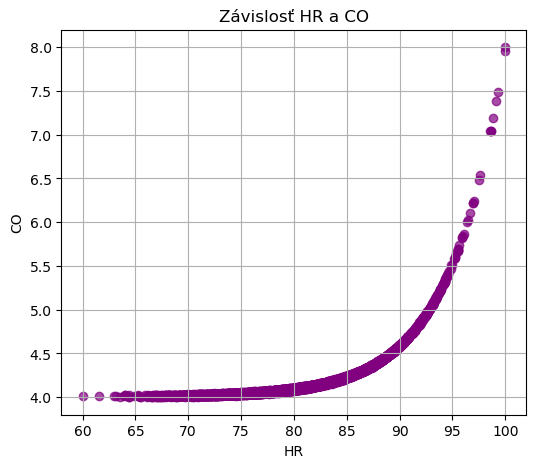

In [284]:
plt.figure(figsize=(6,5))
plt.scatter(x, y, color='purple', alpha=0.7)
plt.title('Závislosť HR a CO')
plt.xlabel('HR')
plt.ylabel('CO')
plt.grid(True)
plt.show()

Tento graf ukazuje veľmi silnú pozitívnu nelineárnu závislosť medzi srdcovou frekvenciou (HR) a srdcovým výdajom (CO).
Vidno, že pri nižších hodnotách HR sa CO mení len minimálne, ale po prekročení určitej hranice (okolo 85-90 úderov/min) začína CO prudko rásť.
To potvrdzuje výsledky Spearmanovho testu – medzi HR a CO existuje silná monotónna, no nie lineárna závislosť.
Preto bol výber Spearmanovej korelácie správny, keďže nezávisí od lineárnosti ani od normálneho rozdelenia dát.

In [285]:
rho, pval = stats.spearmanr(x, y)

print("H0: Medzi HR a CO neexistuje štatisticky významná závislosť.")
print("H1: Existuje štatisticky významná závislosť medzi HR a CO.")

if pval < 0.05:
    print("Výsledok: p < 0.05 → Zamietame H0, existuje štatisticky významná závislosť.")
else:
    print("Výsledok: p ≥ 0.05 = Nezamietame H0, závislosť nie je štatisticky významná.")


H0: Medzi HR a CO neexistuje štatisticky významná závislosť.
H1: Existuje štatisticky významná závislosť medzi HR a CO.
Výsledok: p < 0.05 → Zamietame H0, existuje štatisticky významná závislosť.


# B-1b

In [286]:
x = data['Skin Temperature'].dropna()
y = data['Hb level'].dropna()

r, p_value = stats.pearsonr(x, y)
print(f"Pearson correlation coefficient = {r:.4f}")
print(f"p-value = {p_value:.5e}")

Pearson correlation coefficient = -0.4901
p-value = 0.00000e+00


In [287]:
x = data['HR'].dropna()
y = data['CO'].dropna()

r, p_value = stats.pearsonr(x, y)
print(f"Pearson correlation coefficient = {r:.4f}")
print(f"p-value = {p_value:.5e}")

Pearson correlation coefficient = 0.7632
p-value = 0.00000e+00


Výsledky korelačnej analýzy ukázali, že medzi teplotou pokožky a hladinou hemoglobínu existuje stredne silná negatívna lineárna závislosť (r = -0.4901, p < 0.001), čo znamená, že so zvyšujúcou sa teplotou pokožky má hladina hemoglobínu tendenciu klesať. Naopak, medzi srdcovou frekvenciou (HR) a srdcovým výdajom (CO) bola zistená silná pozitívna korelácia (r = 0.7632, p < 0.001), čo naznačuje, že vyššia srdcová frekvencia je spojená so zvýšeným srdcovým výdajom. V oboch prípadoch bola nulová hypotéza zamietnutá, čo potvrdzuje štatisticky významné vzťahy medzi sledovanými premennými.

In [288]:
x = data['Hb level'].dropna()
y = data['Skin Temperature'].dropna()

cov_matrix = np.cov(x, y)
cov_value = cov_matrix[0, 1]

print(f"Covariance matrix:\n{cov_matrix}")
print(f"Covariance (Hb level, Skin Temperature) = {cov_value:.4f}")

Covariance matrix:
[[ 1.17445    -0.49116476]
 [-0.49116476  0.85514121]]
Covariance (Hb level, Skin Temperature) = -0.4912


In [289]:
x = data['HR'].dropna()
y = data['CO'].dropna()

cov_matrix = np.cov(x, y)
cov_value = cov_matrix[0, 1]

print(f"Covariance matrix:\n{cov_matrix}")
print(f"Covariance (HR, CO) = {cov_value:.4f}")

Covariance matrix:
[[26.59865238  0.80748138]
 [ 0.80748138  0.04208428]]
Covariance (HR, CO) = 0.8075


Kovariančná analýza ukázala, že medzi hladinou hemoglobínu a teplotou pokožky existuje záporná kovariancia (-0.4912), čo znamená, že tieto premenné majú tendenciu meniť sa opačným smerom - so zvyšujúcou sa teplotou pokožky sa hodnota hemoglobínu znižuje. Na druhej strane, medzi srdcovou frekvenciou (HR) a srdcovým výdajom (CO) bola zistená kladná kovariancia (0.8075), čo poukazuje na to, že tieto premenné majú tendenciu rásť spoločne - vyššia srdcová frekvencia je spojená so zvýšeným srdcovým výdajom. Tieto výsledky podporujú aj zistenia z korelačnej analýzy, ktorá potvrdila významné lineárne vzťahy medzi sledovanými premennými.

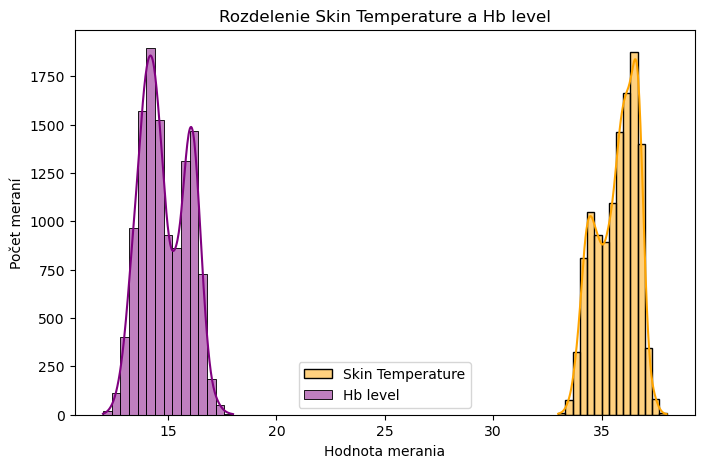

Cohen's d = 20.6946
Veľký efekt


In [290]:
x = data['Skin Temperature'].dropna()
y = data['Hb level'].dropna()

def cohend(d1, d2):
    n1, n2 = len(d1), len(d2)
    s1, s2 = var(d1, ddof=1), var(d2, ddof=1)
    s = sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    u1, u2 = mean(d1), mean(d2)
    d = (u1 - u2) / s
    return d

cd = cohend(x, y)

plt.figure(figsize=(8,5))
sns.histplot(x, bins=15, color="orange", label="Skin Temperature", kde=True)
sns.histplot(y, bins=15, color="purple", label="Hb level", kde=True)
plt.legend()
plt.xlabel("Hodnota merania")
plt.ylabel("Počet meraní")
plt.title("Rozdelenie Skin Temperature a Hb level")
plt.show()

print(f"Cohen's d = {cd:.4f}")

if 0.2 <= abs(cd) < 0.5:
    print("Malý efekt")
elif 0.5 <= abs(cd) < 0.8:
    print("Stredný efekt")
elif abs(cd) >= 0.8:
    print("Veľký efekt")
else:
    print("Veľmi malý alebo žiadny efekt")


Hodnota Cohen’s d = 20.69 je nerealisticky vysoká, pretože premenné Hb level a Skin Temperature sú vyjadrené v rôznych jednotkách (g/dL a °C). Rozdiel v mierkach spôsobuje umelé zväčšenie efektu. Preto tento výsledok nie je vhodné interpretovať ako skutočne veľký efekt.

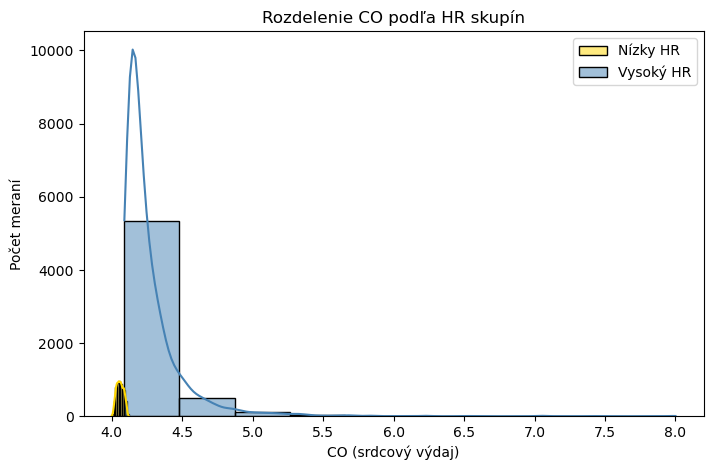

Cohen's d = -1.2247
Veľký efekt


In [291]:
group1 = data[data['HR'] < data['HR'].median()]['CO']
group2 = data[data['HR'] >= data['HR'].median()]['CO']

def cohend(d1, d2):
    n1, n2 = len(d1), len(d2)
    s1, s2 = var(d1, ddof=1), var(d2, ddof=1)
    s = sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    u1, u2 = mean(d1), mean(d2)
    d = (u1 - u2) / s
    return d

cd = cohend(group1, group2)

plt.figure(figsize=(8,5))
sns.histplot(group1, bins=10, color="gold", label="Nízky HR", kde=True)
sns.histplot(group2, bins=10, color="steelblue", label="Vysoký HR", kde=True)
plt.legend()
plt.xlabel("CO (srdcový výdaj)")
plt.ylabel("Počet meraní")
plt.title("Rozdelenie CO podľa HR skupín")
plt.show()

print(f"Cohen's d = {cd:.4f}")

if 0.2 <= abs(cd) < 0.5:
    print("Malý efekt")
elif 0.5 <= abs(cd) < 0.8:
    print("Stredný efekt")
elif abs(cd) >= 0.8:
    print("Veľký efekt")
else:
    print("Veľmi malý alebo žiadny efekt")


Hodnota Cohen’s d = -1.22 naznačuje veľký efekt, čo znamená, že medzi porovnávanými skupinami existuje výrazný rozdiel. Záporné znamienko len ukazuje smer rozdielu (t. j. ktorá skupina má vyššie hodnoty), nie jeho veľkosť - preto môžeme povedať, že ide o silný rozdielový efekt medzi premennými.